In [1]:
import csv
import h5py
import json

import matplotlib.pyplot as plt
import numpy as np

from datetime import datetime
import shutil
import os

In [2]:
def backup_data(data_filename):
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    filename_only = os.path.basename(data_filename)
    name, ext = os.path.splitext(filename_only)
    backup_name = f"{name}_{timestamp}{ext}"
    backup_path = os.path.join('data_backups', backup_name)
    shutil.copy2(data_filename, backup_path)

def save_nested_dict_to_hdf5(filename, data, save_backup=True):

    if save_backup:
        backup_data(filename)

    with h5py.File(filename, 'w') as f:
        def _save_dict(group, dictionary):
            for key, value in dictionary.items():
                if isinstance(value, dict):
                    subgroup = group.create_group(str(key))
                    _save_dict(subgroup, value)
                elif isinstance(value, np.ndarray):
                    group.create_dataset(key, data=value, compression='gzip')
                elif isinstance(value, list):
                    group.create_dataset(key, data=np.array(value), compression='gzip')
                else:
                    group.attrs[key] = value  # Store scalars as attributes
        
        _save_dict(f, data)

def update_data_file(filename, data, keys, save_backup=True):
    if save_backup:
        backup_data(filename)
    
    with h5py.File(filename, 'a') as f:  # Open in append mode
        def _navigate_to_parent(group, key_path):
            """Navigate to the parent group of the target location"""
            current_group = group
            for key in key_path[:-1]:  # All keys except the last one
                if str(key) in current_group:
                    current_group = current_group[str(key)]
                else:
                    # Create the group if it doesn't exist
                    current_group = current_group.create_group(str(key))
            return current_group
        
        def _save_data_at_location(group, key, value):
            """Save data at a specific location, replacing if it exists"""
            # Remove existing data if it exists
            if key in group:
                del group[key]
            
            # Save new data
            if isinstance(value, dict):
                subgroup = group.create_group(key)
                _save_dict(subgroup, value)
            elif isinstance(value, np.ndarray):
                group.create_dataset(key, data=value, compression='gzip')
            elif isinstance(value, list):
                group.create_dataset(key, data=np.array(value), compression='gzip')
            else:
                group.attrs[key] = value  # Store scalars as attributes
        
        def _save_dict(group, dictionary):
            """Helper function to save nested dictionaries"""
            for key, value in dictionary.items():
                _save_data_at_location(group, str(key), value)
        
        # Navigate to the parent location
        parent_group = _navigate_to_parent(f, keys)
        
        # Save the data at the final key location
        final_key = str(keys[-1])
        _save_data_at_location(parent_group, final_key, data)

def load_nested_dict_from_hdf5(filename):
    def _load_dict(group):
        result = {}
        for key in group.keys():
            if isinstance(group[key], h5py.Group):
                result[key] = _load_dict(group[key])
            else:
                result[key] = group[key][()]  # Load dataset
        
        # Load attributes (scalars)
        for key, value in group.attrs.items():
            result[key] = value
            
        return result
    
    with h5py.File(filename, 'r') as f:
        return _load_dict(f)

def print_tree(data, max_level=None):
    def __print_tree_recursive(root, level=0):
        if isinstance(root, dict):
            if not max_level is None and level == max_level:
                return
            level_str = '- '*level
            for key in root:
                print(f'{level_str}{key}')
                __print_tree_recursive(root[key], level+1)
    __print_tree_recursive(data)

In [3]:
data_filename = 'bond_order_data.h5'

data = load_nested_dict_from_hdf5(data_filename)
print_tree(data)

data
- coupling_point_1
- - highest
- - - (1, 2)
- - - - population_difference
- - - - readout_error_means
- - - - readout_error_stds
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - - bond_order_value_readout_std_error
- - - (2, 3)
- - - - population_difference
- - - - readout_error_means
- - - - readout_error_stds
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - - bond_order_value_readout_std_error
- - - (3, 4)
- - - - population_difference
- - - - readout_error_means
- - - - readout_error_stds
- - - - times
- - - - beamsplitter_time
- - - - bond_order_error
- - - - bond_order_error_corrected
- - - - bond_order_value
- - - - bond_order_value_corrected
- - - - bond_order_value_readout_std_error
- - - (4, 5)
- - - - population_difference
- - - - readout_er

In [4]:
# cp_2_sim_data = data['simulation'][eigenstate][dephasing]['coupling_point_2']


In [5]:
# data_filename = 'bond_order_data.h5'

# keys = ('simulation', eigenstate, dephasing, 'coupling_point_2_retake')

# update_data_file(data_filename, cp_2_sim_data, keys=keys, save_backup=True)

In [6]:
# print_tree(data['simulation'], max_level=4)
print_tree(data['simulation']['highest']['real'], max_level=1)

coupling_point_1
coupling_point_2
coupling_point_2_retake
coupling_point_3
coupling_point_4
coupling_point_5
coupling_point_5_retake
coupling_point_6
coupling_point_6_retake


In [7]:
eigenstate = 'highest_postselection'
# eigenstate = 'highest'
eigenstate_base = eigenstate.split('_')[0]

[(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8)]
found in coupling point coupling_point_1
found in coupling point coupling_point_1
found in coupling point coupling_point_1
found in coupling point coupling_point_1
found in coupling point coupling_point_1
found in coupling point coupling_point_1
found in coupling point coupling_point_1


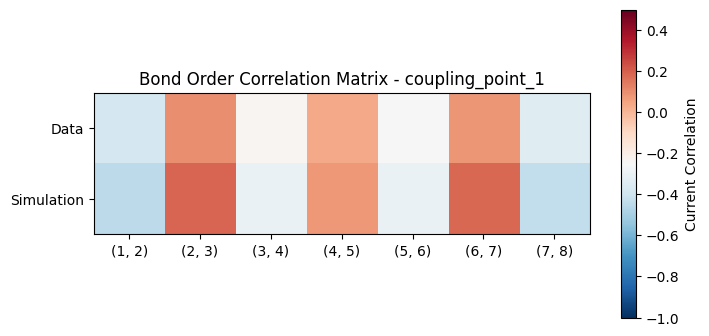

found in coupling point base
found in coupling point base
found in coupling point base
found in coupling point base
found in coupling point base
found in coupling point base
found in coupling point base


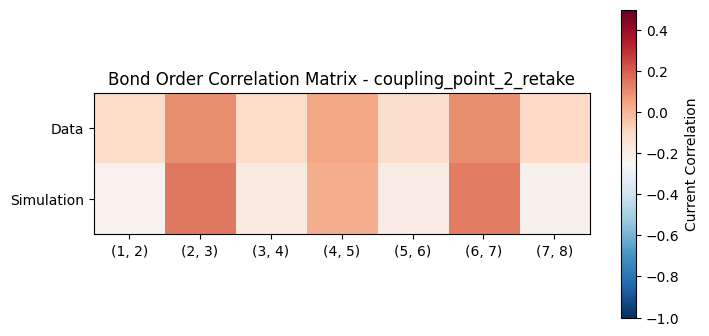

found in coupling point coupling_point_3
found in coupling point coupling_point_3
found in coupling point coupling_point_3
found in coupling point coupling_point_3
found in coupling point coupling_point_3
found in coupling point coupling_point_3
found in coupling point coupling_point_3


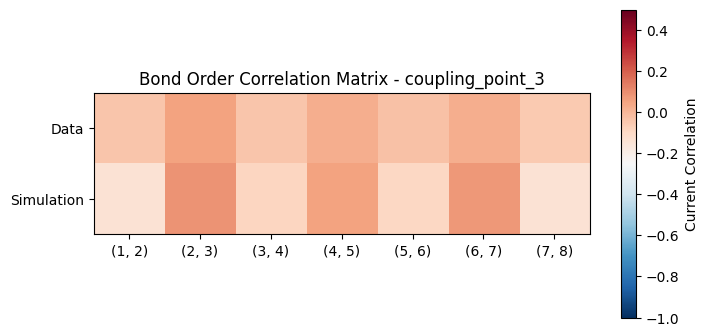

found in coupling point coupling_point_4
found in coupling point coupling_point_4
found in coupling point coupling_point_4
found in coupling point coupling_point_4
found in coupling point coupling_point_4
found in coupling point coupling_point_4
found in coupling point coupling_point_4


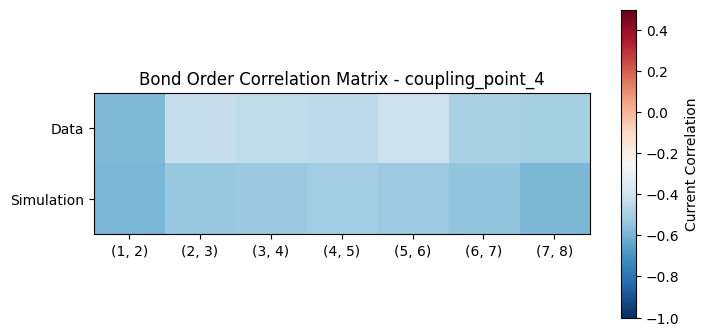

found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake
found in coupling point coupling_point_5_retake


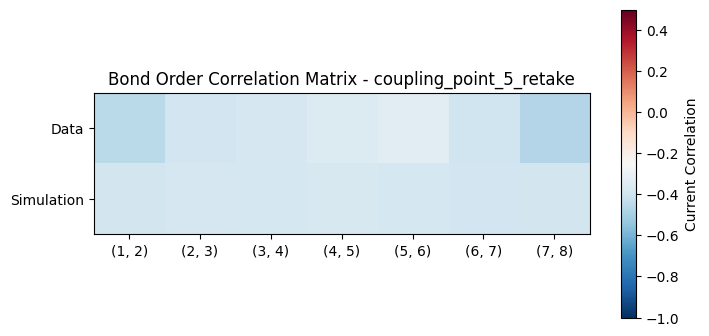

found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake
found in coupling point coupling_point_6_retake


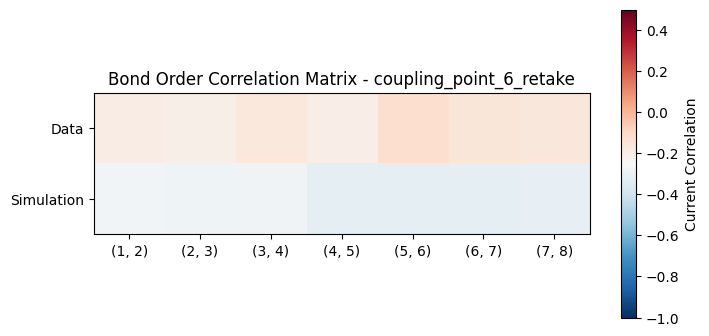

Max bond order value across all coupling points: 0.18497340135577356
Min bond order value across all coupling points: -0.5926087397175466


In [9]:
all_coupling_points = [
    'coupling_point_1',
    'coupling_point_2_retake',
    'coupling_point_3',
    'coupling_point_4',
    'coupling_point_5_retake',
    'coupling_point_6_retake'
]

all_pairs = [(i,i+1) for i in range(1,8)]
print(all_pairs)

dephasing = 'real'

max_value = -np.inf
min_value = np.inf

for coupling_point in all_coupling_points:

    if coupling_point in data['data']:

        # remove _retake suffix
        if '_retake' in coupling_point:
            coupling_point_base = coupling_point.rsplit('_', 1)[0]
        else:
            coupling_point_base = coupling_point

        coupling_point_data = data['data'][coupling_point][eigenstate]
        coupling_point_sim = data['simulation'][eigenstate_base][dephasing][coupling_point]

        # first row is data, second row is simulation
        bond_order_matrix = np.zeros((2, len(all_pairs)))

        bond_order_readout_errors = []

        for i in range(len(all_pairs)):

            pair = all_pairs[i]

            bond_order_data = coupling_point_data[str(pair)]['bond_order_value_corrected']
            bond_order_sim_BS = coupling_point_sim[str(pair)]['bond_order_value_BS']

            if 'bond_order_value_readout_std_error' in coupling_point_data[str(pair)]:
                print(f'found in coupling point {coupling_point}')
                bond_order_readout_errors.append(coupling_point_data[str(pair)]['bond_order_value_readout_std_error'])
            elif 'bond_order_value_readout_std_error' in data['data'][coupling_point_base][eigenstate][str(pair)]:
                print(f'found in coupling point base')
                bond_order_readout_errors.append(data['data'][coupling_point_base][eigenstate][str(pair)]['bond_order_value_readout_std_error'])
            else:
                raise KeyError(f"Readout error std error not found for pair {pair} in coupling point {coupling_point} or base coupling point {coupling_point_base}")

            bond_order_matrix[0, i] = bond_order_data
            bond_order_matrix[1, i] = bond_order_sim_BS
    else:
        # for coupling points with no data, fill with randoms for now
        bond_order_matrix = (np.random.rand(2, len(all_pairs)) - 0.5)*0.2


    if np.max(bond_order_matrix) > max_value:
        max_value = np.max(bond_order_matrix)
    if np.min(bond_order_matrix) < min_value:
        min_value = np.min(bond_order_matrix)

    fig, ax = plt.subplots(figsize=(8,4))

    vmin = -1
    vmax = 0.5
    im = ax.imshow(bond_order_matrix, cmap='RdBu_r', vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(all_pairs)))
    ax.set_xticklabels(all_pairs)
    ax.set_yticks(np.arange(2))
    ax.set_yticklabels(['Data', 'Simulation'])
    fig.colorbar(im, ax=ax, label='Current Correlation')

    plt.title(f'Bond Order Correlation Matrix - {coupling_point}')

    plt.show()


    # default is highest eigenstate and real dephasing
    coupling_point_index = coupling_point.split('_')[2]
    bond_order_matrix_filename = f'plots\\bond_order_matrices\\coupling_point_{coupling_point_index}_bond_order_matrix.csv'
    with open(bond_order_matrix_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        for i in range(2):
            row = list(bond_order_matrix[i, :])
            writer.writerow(row)

    bond_order_readout_std_error_filename = f'plots\\bond_order_errors\\coupling_point_{coupling_point_index}_bond_order_readout_std_error.csv'
    with open(bond_order_readout_std_error_filename, 'w', newline='') as csvfile:
        writer = csv.writer(csvfile)
        writer.writerow(bond_order_readout_errors)

print(f'Max bond order value across all coupling points: {max_value}')
print(f'Min bond order value across all coupling points: {min_value}')

In [9]:
# for coupling_point in all_coupling_points:
#     if coupling_point in data['data']:
#         print()
#         print(f'{coupling_point}')
#         print()
#         # print_tree(data['data'][coupling_point]['highest'], max_level=2)
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])

In [10]:
# all_coupling_points = [f'coupling_point_{i}' for i in range(1, 7)]

# all_pairs = [(i,i+1) for i in range(1,8)]
# print(all_pairs)

# dephasing = 'real'

# for coupling_point in all_coupling_points:

#     if coupling_point in data['data']:

#         coupling_point_data = data['data'][coupling_point]['highest']
#         print(data['data'][coupling_point]['highest']['current_correlation_total'])
#         coupling_point_sim = data['simulation']['highest'][dephasing][coupling_point]

#         print(coupling_point)
#         print(coupling_point_data.keys())

#         distance_to_current_correlation_error = coupling_point_data['distance_to_current_correlation_error']
#         distance_to_current_correlation_value = coupling_point_data['distance_to_current_correlation_value']
        
#         current_correlation_averages = coupling_point_data['current_correlation_averages']
    


In [11]:
### export total bond order explicitly

values = []
errors = []
for coupling_point in all_coupling_points:
    if coupling_point in data['data']:
        coupling_point_data = data['data'][coupling_point][eigenstate]
        value = coupling_point_data['bond_order_total']
        if 'bond_order_total_error' in coupling_point_data:
            error = coupling_point_data['bond_order_total_error_corrected']
        else:
            error = 50
    else:
        value = 0
        error = 50
    values.append(value)
    errors.append(error)

print(values)
print(errors)

with open('plots/bond_order_totals.csv', 'w', newline='\n') as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(values)
    writer.writerow(errors)

[1.5352472115493851, 0.6875979289334593, 0.3682642506843443, 0.4261039717871292, 0.25312278091808055, -0.07992029375544374]
[0.017940351527335578, 0.0215214486456909, 0.010308314346234027, 0.013592177527360408, 0.02451697351901111, 0.05216776795651642]


In [13]:
### export time trace simulations


for coupling_point in all_coupling_points:
    print(f'Coupling point: {coupling_point}')
    eigenstate = 'highest'
    dephasing = 'real'
    print(data['simulation'][eigenstate][dephasing][coupling_point].keys())
    times = data['simulation'][eigenstate][dephasing][coupling_point]['times']
    
    population_diff_sim_filename = f'plots/bond_order_time_trace_sim/{coupling_point}_population_difference_simulation.csv'
    with open(population_diff_sim_filename, 'w', newline='\n') as csvfile:
        writer = csv.writer(csvfile)

        print(len(times))
        for pair in all_pairs:
            population_difference_sim = data['simulation'][eigenstate][dephasing][coupling_point][str(pair)]['population_difference']
            writer.writerow(population_difference_sim)
        writer.writerow(times)


Coupling point: coupling_point_1
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', 'bond_order_total', 'bond_order_total_BS'])
201
Coupling point: coupling_point_2_retake
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', 'bond_order_total', 'bond_order_total_BS'])
201
Coupling point: coupling_point_3
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', 'bond_order_total', 'bond_order_total_BS'])
201
Coupling point: coupling_point_4
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', 'bond_order_total', 'bond_order_total_BS'])
201
Coupling point: coupling_point_5_retake
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', 'bond_order_total', 'bond_order_total_BS'])
201
Coupling point: coupling_point_6_retake
dict_keys(['(1, 2)', '(2, 3)', '(3, 4)', '(4, 5)', '(5, 6)', '(6, 7)', '(7, 8)', 'times', '